# 사전 설정

In [12]:
df = pd.read_csv('course_final.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (533578, 21)
Columns: ['course_id', 'userid_DI', 'registered', 'viewed', 'explored', 'certified', 'final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender', 'grade', 'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act', 'nchapters', 'nforum_posts', 'start_year', 'age', 'age_group', 'exam_flag']


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nchapters,nforum_posts,start_year,age,age_group,exam_flag
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,0,2012-09-17,2013-05-23,502.0000,16.0000,12.0000,0,2012,NaN,NaN,1
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,0,2013-01-01,2013-05-14,42.0000,6.0000,3.0000,0,2013,NaN,NaN,1
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0,2013-02-18,2013-03-17,70.0000,3.0000,3.0000,0,2013,NaN,NaN,1
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0,2013-02-23,2013-06-14,17.0000,2.0000,2.0000,0,2013,NaN,NaN,1
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,0,2013-06-17,2013-06-17,32.0000,1.0000,3.0000,0,2013,NaN,NaN,1


# 데이터 구조 파악

In [14]:
print(f"행(관측치): {df.shape[0]:,}")
print(f"열(변수):   {df.shape[1]}")
print(f"\n고유 학습자 수: {df['userid_DI'].nunique():,}")
print(f"고유 코스 수:   {df['course_id'].nunique():,}")
print(f"\n학습자당 평균 등록 코스: {df.groupby('userid_DI')['course_id'].nunique().mean():.2f}")

행(관측치): 533,578
열(변수):   21

고유 학습자 수: 413,587
고유 코스 수:   16

학습자당 평균 등록 코스: 1.29


In [15]:
df.info()

# 타입 불일치 점검
print("\n=== 타입 변환 필요 여부 점검 ===")
print(f"grade dtype: {df['grade'].dtype}")           # object면 변환 필요
print(f"start_time_DI dtype: {df['start_time_DI'].dtype}")  # object면 변환 필요
print(f"last_event_DI dtype: {df['last_event_DI'].dtype}")

<class 'pandas.DataFrame'>
RangeIndex: 533578 entries, 0 to 533577
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   course_id          533578 non-null  str    
 1   userid_DI          533578 non-null  str    
 2   registered         533578 non-null  int64  
 3   viewed             533578 non-null  int64  
 4   explored           533578 non-null  int64  
 5   certified          533578 non-null  int64  
 6   final_cc_cname_DI  533578 non-null  str    
 7   LoE_DI             533578 non-null  str    
 8   YoB                452595 non-null  float64
 9   gender             533578 non-null  str    
 10  grade              490914 non-null  str    
 11  start_time_DI      533578 non-null  str    
 12  last_event_DI      533578 non-null  str    
 13  nevents            533578 non-null  float64
 14  ndays_act          533578 non-null  float64
 15  nchapters          533578 non-null  float64
 16  nforum_posts 

In [18]:
# grade: 문자 → 숫자 (변환 불가값은 NaN 처리)
df['grade'] = pd.to_numeric(df['grade'], errors='coerce')

# 날짜 변환
df['start_time_DI'] = pd.to_datetime(df['start_time_DI'], errors='coerce')
df['last_event_DI'] = pd.to_datetime(df['last_event_DI'], errors='coerce')

# 검증
print(df[['grade', 'start_time_DI', 'last_event_DI']].dtypes)

grade                   float64
start_time_DI    datetime64[us]
last_event_DI    datetime64[us]
dtype: object


In [17]:
# 수치형 변수 기술통계
display(df.describe())

# 범주형 변수 빈도 개관
for col in ['gender', 'LoE_DI', 'final_cc_cname_DI']:
    print(f"\n=== {col} ===")
    print(f"고유값 수: {df[col].nunique()}")
    print(df[col].value_counts(dropna=False).head(10))

,registered,viewed,explored,certified,YoB,grade,start_time_DI,last_event_DI,nevents,ndays_act,nchapters,nforum_posts,start_year,age,exam_flag
count,533578.0000,533578.0000,533578.0000,533578.0000,452595.0000,483131.0000,533578,533578,533578.0000,533578.0000,533578.0000,533578.0000,533578.0000,452595.0000,533578.0000
mean,1.0000,0.6090,0.0697,0.0330,1985.3214,0.0409,2013-01-08 19:27:14.329750,2013-02-17 21:54:33.692693,356.3696,4.8120,2.3472,0.0227,2012.5619,27.2404,0.9200
min,1.0000,0.0000,0.0000,0.0000,1931.0000,0.0000,2012-07-23 00:00:00,2012-07-24 00:00:00,0.0000,0.0000,0.0000,0.0000,2012.0000,0.0000,0.0000
25%,1.0000,0.0000,0.0000,0.0000,1982.0000,0.0000,2012-10-01 00:00:00,2012-10-30 00:00:00,1.0000,1.0000,0.0000,0.0000,2012.0000,21.0000,1.0000
50%,1.0000,1.0000,0.0000,0.0000,1988.0000,0.0000,2013-01-20 00:00:00,2013-03-04 00:00:00,11.0000,1.0000,1.0000,0.0000,2013.0000,25.0000,1.0000
75%,1.0000,1.0000,0.0000,0.0000,1991.0000,0.0000,2013-03-21 00:00:00,2013-05-18 00:00:00,104.0000,4.0000,3.0000,0.0000,2013.0000,30.0000,1.0000
max,1.0000,1.0000,1.0000,1.0000,2013.0000,1.0100,2013-09-07 00:00:00,2013-09-07 00:00:00,197757.0000,205.0000,48.0000,20.0000,2013.0000,82.0000,1.0000
std,0.0000,0.4880,0.2547,0.1787,8.8580,0.1653,NaN,NaN,1388.8577,11.1348,4.1784,0.2511,0.4962,8.8680,0.2712



=== gender ===
고유값 수: 4
gender
m          340030
f          120738
unknown     72802
o               8
Name: count, dtype: int64

=== LoE_DI ===
고유값 수: 6
LoE_DI
Bachelor's             183308
Secondary              139204
Master's               100470
unknown                 87785
Doctorate               11651
Less than Secondary     11160
Name: count, dtype: int64

=== final_cc_cname_DI ===
고유값 수: 34
final_cc_cname_DI
United States                     155502
India                              78969
Unknown/Other                      49197
Other Europe                       35399
Other Africa                       20920
United Kingdom                     19178
Brazil                             15972
Other Middle East/Central Asia     15360
Other South Asia                   11400
Canada                             10590
Name: count, dtype: int64


In [19]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    '결측 수': missing,
    '결측률(%)': missing_pct
}).sort_values('결측률(%)', ascending=False)
missing_df[missing_df['결측 수'] > 0]

,결측 수,결측률(%)
age_group,81309,15.2400
YoB,80983,15.1800
age,80983,15.1800
grade,50447,9.4500


# 단변량 탐색

## 퍼널 플래그 변수

In [21]:
funnel_cols = ['registered', 'viewed', 'explored', 'certified']
funnel_counts = df[funnel_cols].sum()
funnel_rates = (funnel_counts / len(df) * 100).round(2)

funnel_summary = pd.DataFrame({
    '인원 수': funnel_counts.astype(int),
    '비율(%)': funnel_rates
})
display(funnel_summary)

,인원 수,비율(%)
registered,533578,100.0000
viewed,324946,60.9000
explored,37215,6.9700
certified,17619,3.3000


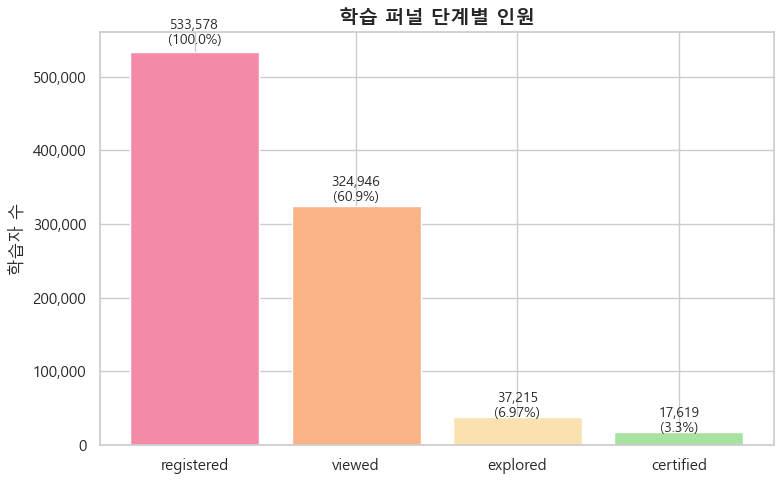

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#f38ba8', '#fab387', '#f9e2af', '#a6e3a1']
ax.bar(funnel_summary.index, funnel_summary['인원 수'], color=colors)

for i, (cnt, pct) in enumerate(zip(funnel_summary['인원 수'], funnel_rates)):
    ax.text(i, cnt + cnt*0.02, f"{cnt:,}\n({pct}%)", ha='center', fontsize=10)

ax.set_title('학습 퍼널 단계별 인원', fontsize=14, fontweight='bold')
ax.set_ylabel('학습자 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [ ]:
stages = ['registered', 'viewed', 'explored', 'certified']
counts = [df[s].sum() for s in stages]

print("=== 단계별 전환율·이탈률 ===")
for i in range(1, len(stages)):
    conv = counts[i] / counts[i-1] * 100
    drop = 100 - conv
    print(f"{stages[i-1]:>12} → {stages[i]:<12}  전환 {conv:5.1f}%  |  이탈 {drop:5.1f}%")

print(f"\n{'전체 퍼널':>12} (Reg→Cert)   전환 {counts[-1]/counts[0]*100:5.1f}%")ㅅ

=== 단계별 전환율·이탈률 ===
  registered → viewed        전환  60.9%  |  이탈  39.1%
      viewed → explored      전환  11.5%  |  이탈  88.5%
    explored → certified     전환  47.3%  |  이탈  52.7%

       전체 퍼널 (Reg→Cert)   전환   3.3%


In [25]:
behavior_cols = ['nevents', 'ndays_act', 'nchapters', 'nforum_posts']

null_zero = pd.DataFrame({
    'NULL 수': df[behavior_cols].isnull().sum(),
    'NULL(%)': (df[behavior_cols].isnull().mean() * 100).round(2),
    '0 수': (df[behavior_cols] == 0).sum(),
    '0(%)': ((df[behavior_cols] == 0).mean() * 100).round(2),
    '양수 수': (df[behavior_cols] > 0).sum(),
    '양수(%)': ((df[behavior_cols] > 0).mean() * 100).round(2)
})
display(null_zero)

,NULL 수,NULL(%),0 수,0(%),양수 수,양수(%)
nevents,0,0.0000,91546,17.1600,442032,82.8400
ndays_act,0,0.0000,91546,17.1600,442032,82.8400
nchapters,0,0.0000,224808,42.1300,308770,57.8700
nforum_posts,0,0.0000,526179,98.6100,7399,1.3900


In [27]:
print("=== 행동 지표 기술통계 ===")
display(df[behavior_cols].describe().T.round(2))

# 평균 vs 중앙값 비교 → 왜도 판단
for col in behavior_cols:
    mean_val = df[col].mean()
    med_val = df[col].median()
    skew_val = df[col].skew()
    print(f"{col:>15}  평균={mean_val:8.2f}  중앙값={med_val:6.1f}  왜도={skew_val:6.2f}")

=== 행동 지표 기술통계 ===


,count,mean,std,min,25%,50%,75%,max
nevents,533578.0000,356.3700,1388.8600,0.0000,1.0000,11.0000,104.0000,197757.0000
ndays_act,533578.0000,4.8100,11.1300,0.0000,1.0000,1.0000,4.0000,205.0000
nchapters,533578.0000,2.3500,4.1800,0.0000,0.0000,1.0000,3.0000,48.0000
nforum_posts,533578.0000,0.0200,0.2500,0.0000,0.0000,0.0000,0.0000,20.0000


        nevents  평균=  356.37  중앙값=  11.0  왜도= 12.71
      ndays_act  평균=    4.81  중앙값=   1.0  왜도=  5.08
      nchapters  평균=    2.35  중앙값=   1.0  왜도=  3.56
   nforum_posts  평균=    0.02  중앙값=   0.0  왜도= 23.56


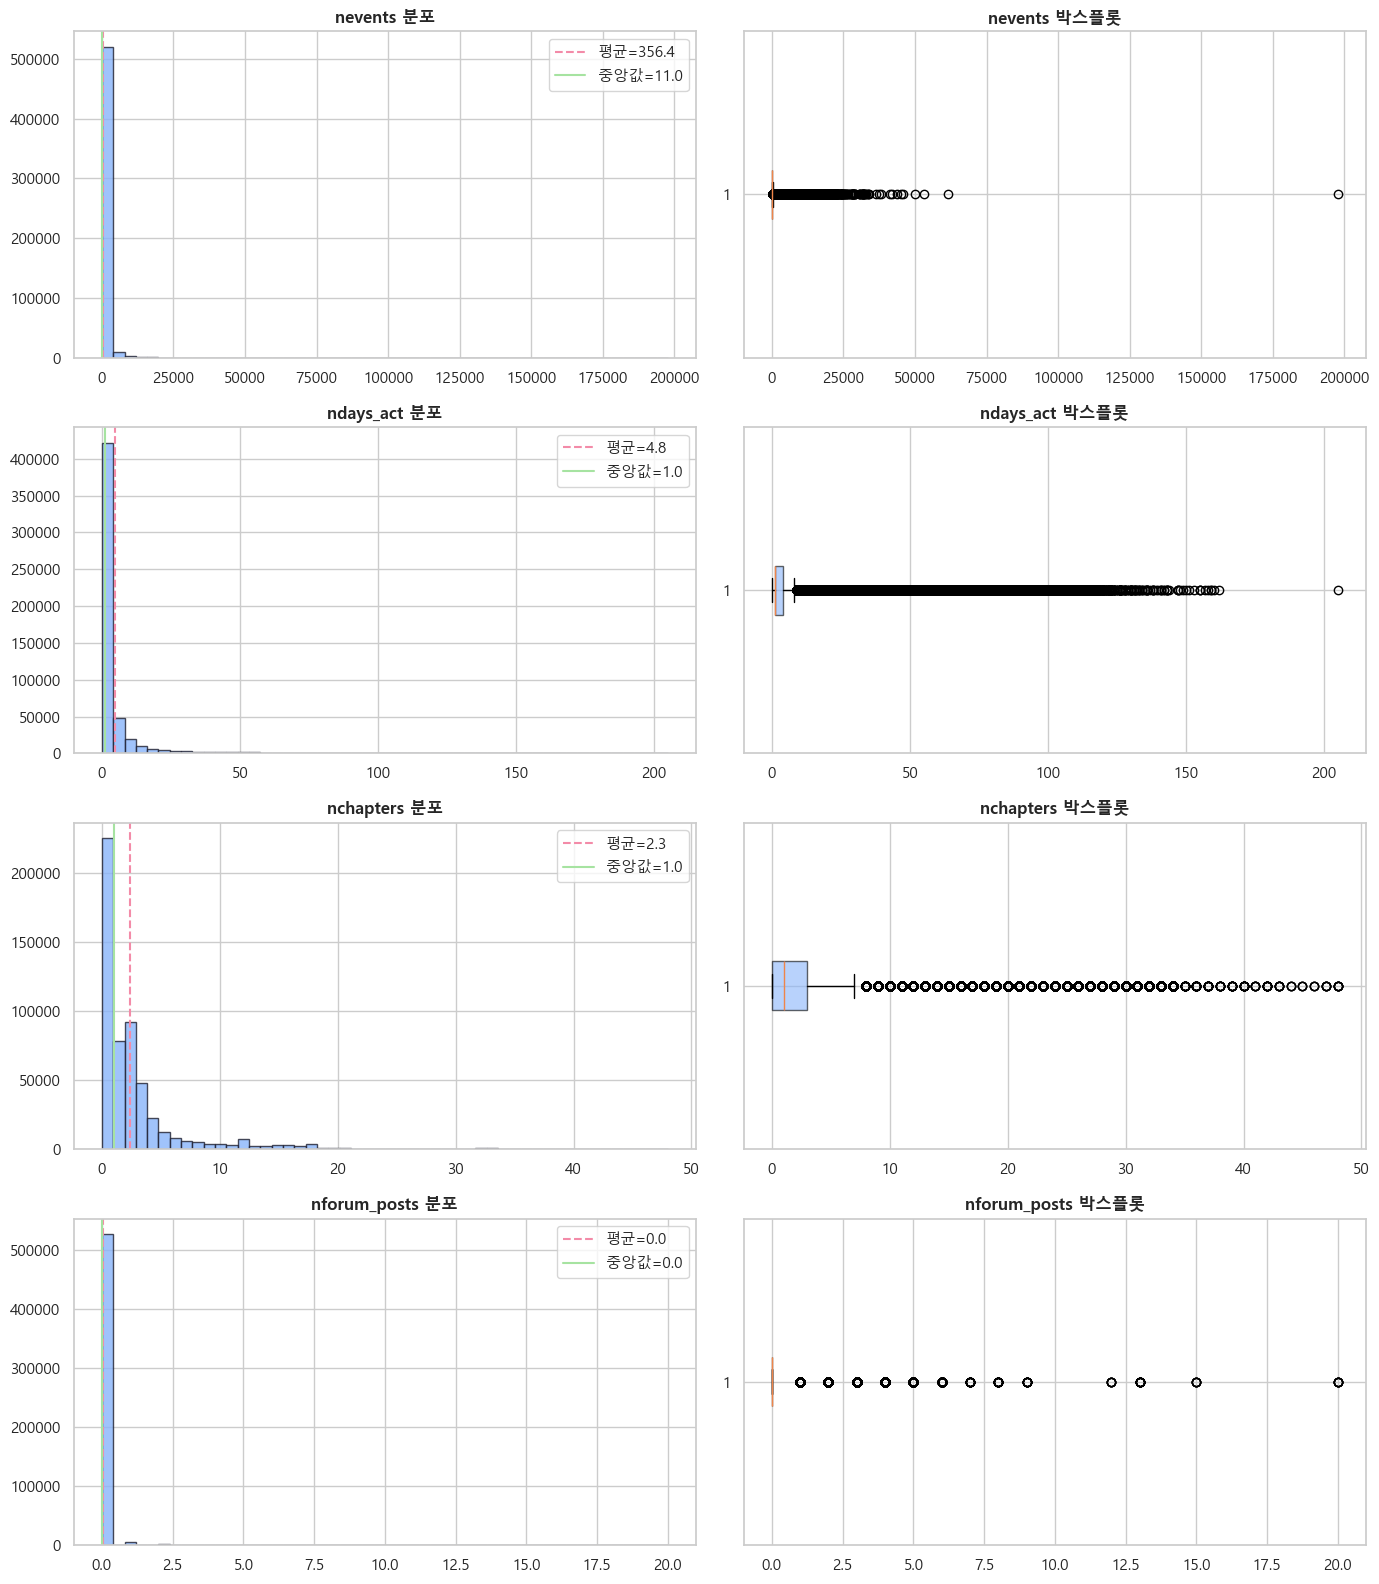

In [28]:
fig, axes = plt.subplots(len(behavior_cols), 2, figsize=(14, 4*len(behavior_cols)))

for i, col in enumerate(behavior_cols):
    data = df[col].dropna()

    # 히스토그램
    axes[i, 0].hist(data, bins=50, color='#89b4fa', edgecolor='#1e1e2e', alpha=0.8)
    axes[i, 0].axvline(data.mean(), color='#f38ba8', linestyle='--', label=f'평균={data.mean():.1f}')
    axes[i, 0].axvline(data.median(), color='#a6e3a1', linestyle='-', label=f'중앙값={data.median():.1f}')
    axes[i, 0].set_title(f'{col} 분포', fontweight='bold')
    axes[i, 0].legend()

    # 박스플롯
    axes[i, 1].boxplot(data, vert=False, patch_artist=True,
                        boxprops=dict(facecolor='#89b4fa', alpha=0.6))
    axes[i, 1].set_title(f'{col} 박스플롯', fontweight='bold')

plt.tight_layout()
plt.show()

In [30]:
print("=== grade 전체 기술통계 ===")
display(df['grade'].describe())

print(f"\ngrade NULL 수: {df['grade'].isnull().sum()}")
print(f"grade = 0 수:  {(df['grade'] == 0).sum()}")
print(f"grade > 0 수:  {(df['grade'] > 0).sum()}")

# grade > 0 서브셋
grade_pos = df.loc[df['grade'] > 0, 'grade']
print(f"\n=== grade > 0 기술통계 ===")
display(grade_pos.describe())

=== grade 전체 기술통계 ===


count   483131.0000
mean         0.0409
std          0.1653
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0100
Name: grade, dtype: float64


grade NULL 수: 50447
grade = 0 수:  409321
grade > 0 수:  73810

=== grade > 0 기술통계 ===


count   73810.0000
mean        0.2678
std         0.3436
min         0.0100
25%         0.0100
50%         0.0600
75%         0.5200
max         1.0100
Name: grade, dtype: float64

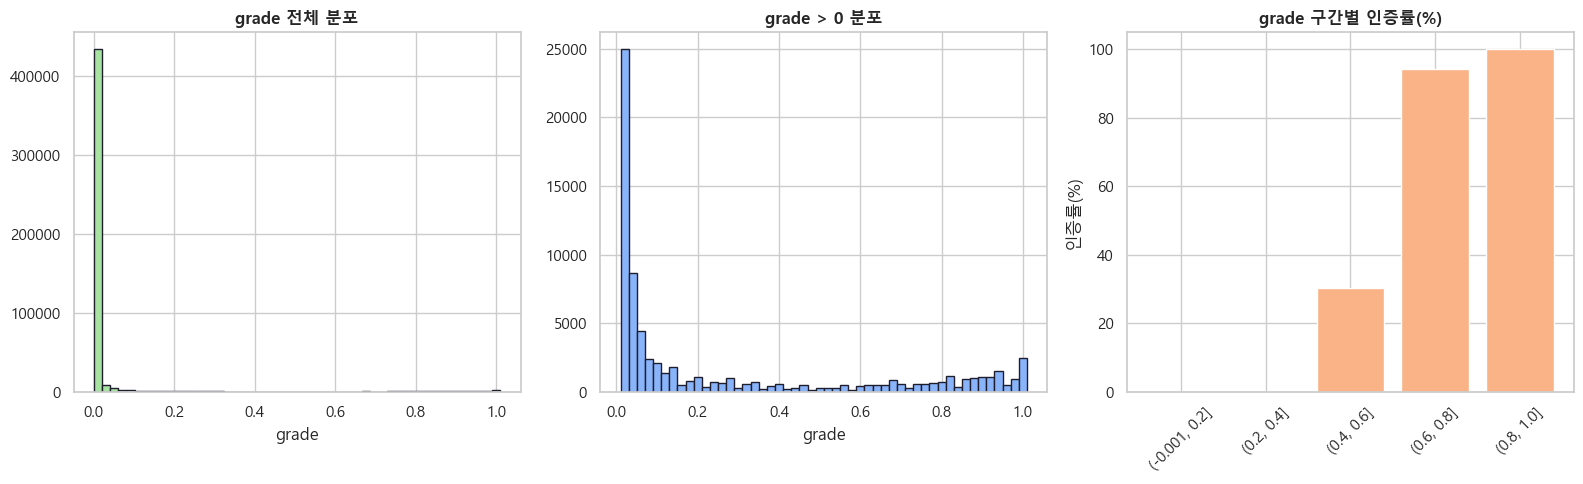

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 전체 grade 분포
axes[0].hist(df['grade'].dropna(), bins=50, color='#a6e3a1', edgecolor='#1e1e2e')
axes[0].set_title('grade 전체 분포', fontweight='bold')
axes[0].set_xlabel('grade')

# grade > 0 분포
axes[1].hist(grade_pos, bins=50, color='#89b4fa', edgecolor='#1e1e2e')
axes[1].set_title('grade > 0 분포', fontweight='bold')
axes[1].set_xlabel('grade')

# grade 구간별 인증률
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
df['grade_bin'] = pd.cut(df['grade'], bins=bins, include_lowest=True)
cert_by_grade = df.groupby('grade_bin', observed=True)['certified'].mean() * 100
axes[2].bar(range(len(cert_by_grade)), cert_by_grade.values, color='#fab387')
axes[2].set_xticks(range(len(cert_by_grade)))
axes[2].set_xticklabels([str(b) for b in cert_by_grade.index], rotation=45)
axes[2].set_title('grade 구간별 인증률(%)', fontweight='bold')
axes[2].set_ylabel('인증률(%)')

plt.tight_layout()
plt.show()

In [32]:
cert_counts = df['certified'].value_counts()
cert_rate = df['certified'].mean() * 100
print(f"인증 획득: {cert_counts.get(1, 0):,} ({cert_rate:.2f}%)")
print(f"미인증:    {cert_counts.get(0, 0):,} ({100-cert_rate:.2f}%)")

인증 획득: 17,619 (3.30%)
미인증:    515,959 (96.70%)


### 인구통계

In [ ]:
display(df['gender'].value_counts(dropna=False))
print(f"\n결측률: {df['gender'].isnull().mean()*100:.2f}%")

gender
m          340030
f          120738
unknown     72802
o               8
Name: count, dtype: int64


결측률: 0.00%


In [ ]:
print(df['LoE_DI'].value_counts(dropna=False))
print(f"\n결측률: {df['LoE_DI'].isnull().mean()*100:.2f}%")

count   452595.0000
mean      1985.3214
std          8.8580
min       1931.0000
25%       1982.0000
50%       1988.0000
75%       1991.0000
max       2013.0000
Name: YoB, dtype: float64

결측률: 15.18%
최솟값: 1931.0, 최댓값: 2013.0

유효 범위(1940~2010) 비율: 84.7%


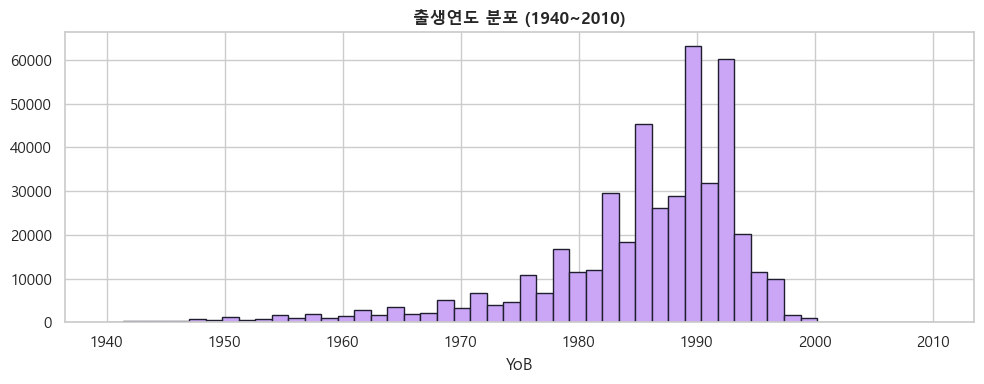

In [35]:
print(df['YoB'].describe())
print(f"\n결측률: {df['YoB'].isnull().mean()*100:.2f}%")
print(f"최솟값: {df['YoB'].min()}, 최댓값: {df['YoB'].max()}")

# 합리적 범위 내 분포
yob_valid = df.loc[df['YoB'].between(1940, 2010), 'YoB']
print(f"\n유효 범위(1940~2010) 비율: {len(yob_valid)/len(df)*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(yob_valid, bins=50, color='#cba6f7', edgecolor='#1e1e2e')
ax.set_title('출생연도 분포 (1940~2010)', fontweight='bold')
ax.set_xlabel('YoB')
plt.tight_layout()
plt.show()

In [301]:
# 1. 타겟 누수 점검: 원본 df 그대로 사용 (데이터 수집 시스템 자체의 문제 여부 확인)
# ✅ 분석 전용 데이터프레임 생성: gender == 'o' 행 제외 (원본 df는 보존)
df_analysis = df[df['gender'] != 'o'].copy()

check_df = df.copy()
check_df['is_missing_profile'] = check_df[['age', 'gender', 'LoE_DI', 'final_cc_cname_DI']].isnull().any(axis=1)

leakage_check = check_df.groupby('viewed')['is_missing_profile'].mean() * 100
print("[1. 타겟 누수(Target Leakage) 의혹 점검]")
print(f"- View=1 (조회 성공) 집단의 프로필 누락 비율: {leakage_check[1]:.1f}%")
print(f"- View=0 (조회 실패) 집단의 프로필 누락 비율: {leakage_check[0]:.1f}%")

if abs(leakage_check[1] - leakage_check[0]) > 30:
    print(" 🚨 비상! 두 집단 간 결측률 차이가 비정상적으로 큽니다.")
else:
    print(" ✅ 정상! 결측률이 비슷비슷합니다. 타겟 누수 걱정은 접어두셔도 좋습니다.\n")


# 2. 생존자 편향 점검: df_analysis 기준으로 변경 (실제 분석 모수와 동일하게 맞춤)
# df_analysis 기반 베이스라인 재산출
analysis_total = len(df_analysis)
analysis_viewed = df_analysis['viewed'].sum()
analysis_base_rate = analysis_viewed / analysis_total * 100

# dropna 후 생존 집단의 전환율 산출
alive_df = df_analysis[['viewed', 'age', 'gender', 'LoE_DI', 'final_cc_cname_DI']].dropna()
alive_view_rate = alive_df['viewed'].mean() * 100

print("[2. 생존자 편향(Selection Bias) 의혹 점검]")
print(f"- df_analysis 전체 베이스라인 View 전환율: {analysis_base_rate:.2f}%")
print(f"- dropna 후 생존 집단의 View 전환율: {alive_view_rate:.2f}%")

if abs(analysis_base_rate - alive_view_rate) > 5:
    print(" 🚨 비상! 회귀분석 해석 시 생존자 편향에 주의가 필요합니다.")
else:
    print(" ✅ 정상! 결측치가 무작위로 분포(MCAR)하여 분석 신뢰도에 문제가 없습니다.")


[1. 타겟 누수(Target Leakage) 의혹 점검]
- View=1 (조회 성공) 집단의 프로필 누락 비율: 17.2%
- View=0 (조회 실패) 집단의 프로필 누락 비율: 12.1%
 ✅ 정상! 결측률이 비슷비슷합니다. 타겟 누수 걱정은 접어두셔도 좋습니다.

[2. 생존자 편향(Selection Bias) 의혹 점검]
- df_analysis 전체 베이스라인 View 전환율: 60.93%
- dropna 후 생존 집단의 View 전환율: 59.51%
 ✅ 정상! 결측치가 무작위로 분포(MCAR)하여 분석 신뢰도에 문제가 없습니다.


In [303]:
print(f"[전처리] gender='o' 제외 후 분석 대상: {len(df_analysis):,}명 (제외된 행: {len(df) - len(df_analysis):,}명)\n")

print("■ 카이제곱 검정 '기대 빈도(Expected Frequency) 5 이상' 필수 조건 팩트체크 ■\n")

cat_vars = ['gender', 'LoE_DI', 'age_group', 'final_cc_cname_DI'] 

for var in cat_vars:
    # 1. df_analysis 기준으로 결측치 임시 제거 후 원본 교차표 생성
    temp_df = df_analysis[[var, 'viewed']].dropna()
    crosstab = pd.crosstab(temp_df[var], temp_df['viewed'])
    
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    
    print(f"[{var} 집단의 관측 전제조건(기대 빈도) 검사]")
    
    expected_df = pd.DataFrame(
        expected, 
        index=crosstab.index, 
        columns=['View=0 (기대 인원)', 'View=1 (기대 인원)']
    ).round(1)
    
    display(expected_df)
    
    invalid_cells = (expected < 5).sum()
    total_cells = expected.size
    
    print(f"👉 전체 {total_cells}개의 칸(Cell) 중, '5명 미만'인 칸 개수: {invalid_cells}개")
    
    if invalid_cells > 0:
        print(f"🚨 [경고] {var} 검정 무효! 기대 빈도가 부족하여 Fisher's Exact Test로 대체해야 합니다.\n")
    else:
        print(f"✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!\n")
        
    print("-" * 65 + "\n")


[전처리] gender='o' 제외 후 분석 대상: 533,985명 (제외된 행: 8명)

■ 카이제곱 검정 '기대 빈도(Expected Frequency) 5 이상' 필수 조건 팩트체크 ■

[gender 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
gender,,
f,47201.7000,73611.3000
m,132958.8000,207350.2000
unknown,28467.6000,44395.4000


👉 전체 6개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[LoE_DI 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
LoE_DI,,
Bachelor's,71665.7000,111763.3000
Doctorate,4555.2000,7103.8000
Less than Secondary,4363.7000,6805.3000
Master's,39286.5000,61267.5000
Secondary,54432.7000,84888.3000
unknown,34324.2000,53528.8000


👉 전체 12개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[age_group 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
age_group,,
20s,105324.9000,164255.1000
30s,33706.1000,52564.9000
40s,9947.6000,15513.4000
50s,4227.0000,6592.0000
60_plus,1839.8000,2869.2000
under_20,21917.1000,34179.9000
unknown,31665.5000,49382.5000


👉 전체 14개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------

[final_cc_cname_DI 집단의 관측 전제조건(기대 빈도) 검사]


,View=0 (기대 인원),View=1 (기대 인원)
final_cc_cname_DI,,
Australia,2141.4000,3339.6000
Bangladesh,1023.2000,1595.8000
Brazil,6242.6000,9735.4000
Canada,4143.4000,6461.6000
China,1859.7000,2900.3000
Colombia,1670.6000,2605.4000
Egypt,3219.8000,5021.2000
France,1581.9000,2467.1000
Germany,2822.0000,4401.0000


👉 전체 68개의 칸(Cell) 중, '5명 미만'인 칸 개수: 0개
✅ [안전 통과] 5명 미만인 칸이 단 하나도 없어 통계 검정에 흠결이 없습니다!

-----------------------------------------------------------------



In [ ]:
# high_risk 분류 (이전 셀이 실행된 상태)
high_risk_group = viewed_df[viewed_df['high_risk'] == 1]['explored']
low_risk_group  = viewed_df[viewed_df['high_risk'] == 0]['explored']

# 1. 전환율 비교
high_rate = high_risk_group.mean() * 100
low_rate  = low_risk_group.mean()  * 100

print("■ High Risk vs Low Risk 탐색(Explored) 전환율 비교 ■\n")
print(f"  High Risk 집단: {high_rate:.2f}%  ({viewed_df['high_risk'].sum():,}명)")
print(f"  Low Risk  집단: {low_rate:.2f}%  ({(viewed_df['high_risk']==0).sum():,}명)")
print(f"  전환율 차이(Gap): {low_rate - high_rate:.2f}%p\n")

# 2. 카이제곱 검정 + Cramer's V
crosstab = pd.crosstab(viewed_df['high_risk'], viewed_df['explored'])
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
cramers_v = np.sqrt(chi2 / (crosstab.sum().sum() * (min(crosstab.shape) - 1)))

# 3. Odds Ratio
a = crosstab.loc[1, 1]  # high_risk=1, explored=1
b = crosstab.loc[1, 0]  # high_risk=1, explored=0
c = crosstab.loc[0, 1]  # high_risk=0, explored=1
d = crosstab.loc[0, 0]  # high_risk=0, explored=0
odds_ratio = (a * d) / (b * c)

print("■ 통계 검정 결과 ■\n")
print(f"  P-value:     {p_val:.5e}")
print(f"  Cramer's V:  {cramers_v:.3f}  {'🔥 Large' if cramers_v>=0.5 else '🔸 Medium' if cramers_v>=0.3 else '🔹 Small' if cramers_v>=0.1 else '💧 Trivial'}")
print(f"  Odds Ratio:  {odds_ratio:.3f}배  (1보다 클수록 Low Risk가 탐색 전환에 유리)")


■ High Risk vs Low Risk 탐색(Explored) 전환율 비교 ■

  High Risk 집단: 1.48%  (101,973명)
  Low Risk  집단: 16.15%  (223,388명)
  전환율 차이(Gap): 14.67%p

■ 통계 검정 결과 ■

  P-value:     0.00000e+00
  Cramer's V:  0.213  🔹 Small
  Odds Ratio:  0.078배  (1보다 클수록 Low Risk가 탐색 전환에 유리)
